## Read in ERA5 monthly averaged parameterized heating profiles and write climo/nino/nina averaged files to output ncetdf file, in correct format for vproc climo diagnostics

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import csv as csv

# Create a list of month names for column headers
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Load the data into a Pandas DataFrame

data_sst0 = csv.reader("ssta_obs_data.csv")
data_sst0 = pd.read_csv("ssta_obs_data.csv",delim_whitespace=True,header=None,index_col=0,names=['Month'] + months)

data_sst0

/glade/derecho/scratch/rneale/tmp/ipykernel_34047/101738614.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_sst0 = pd.read_csv("ssta_obs_data.csv",delim_whitespace=True,header=None,index_col=0,names=['Month'] + months)


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Month,,,,,,,,,,,,
1948,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99
1949,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99
1950,-1.99,-1.69,-1.42,-1.54,-1.75,-1.27,-1.01,-0.97,-0.98,-1.03,-1.23,-1.31
1951,-1.30,-1.04,-0.38,-0.23,-0.01,0.00,0.30,0.17,0.51,0.49,0.55,0.31
1952,0.13,-0.01,-0.11,-0.02,-0.14,-0.54,-0.76,-0.56,-0.36,-0.46,-0.78,-0.39
...,...,...,...,...,...,...,...,...,...,...,...,...
2020,0.60,0.37,0.48,0.36,-0.27,-0.34,-0.30,-0.59,-0.83,-1.26,-1.42,-1.15
2021,-1.00,-1.00,-0.80,-0.72,-0.46,-0.28,-0.39,-0.53,-0.55,-0.94,-0.94,-1.06
2022,-0.94,-0.89,-0.97,-1.11,-1.11,-0.75,-0.69,-0.97,-1.07,-0.99,-0.90,-0.85


In [3]:
# Flatten data to 1D continuous
data_sst = data_sst0.values.flatten()
data_sst

array([-9.999e+01, -9.999e+01, -9.999e+01, -9.999e+01, -9.999e+01,
       -9.999e+01, -9.999e+01, -9.999e+01, -9.999e+01, -9.999e+01,
       -9.999e+01, -9.999e+01, -9.999e+01, -9.999e+01, -9.999e+01,
       -9.999e+01, -9.999e+01, -9.999e+01, -9.999e+01, -9.999e+01,
       -9.999e+01, -9.999e+01, -9.999e+01, -9.999e+01, -1.990e+00,
       -1.690e+00, -1.420e+00, -1.540e+00, -1.750e+00, -1.270e+00,
       -1.010e+00, -9.700e-01, -9.800e-01, -1.030e+00, -1.230e+00,
       -1.310e+00, -1.300e+00, -1.040e+00, -3.800e-01, -2.300e-01,
       -1.000e-02,  0.000e+00,  3.000e-01,  1.700e-01,  5.100e-01,
        4.900e-01,  5.500e-01,  3.100e-01,  1.300e-01, -1.000e-02,
       -1.100e-01, -2.000e-02, -1.400e-01, -5.400e-01, -7.600e-01,
       -5.600e-01, -3.600e-01, -4.600e-01, -7.800e-01, -3.900e-01,
        2.000e-01,  2.400e-01,  2.900e-01,  2.200e-01,  3.500e-01,
        3.900e-01,  1.400e-01,  9.000e-02,  2.900e-01,  1.600e-01,
        1.800e-01,  4.100e-01,  4.300e-01,  2.800e-01, -3.800e

In [4]:
# Construct time series coordinate similar format to input ERA data
start_year_s = 1948
end_year_s = 2024

start_year_e5 = 1980
end_year_e5 = 2020

dates_sst = np.arange(f'{start_year_s}-01', f'{end_year_s+1}-01', dtype='datetime64[M]')
xdata_sst = xr.DataArray(data_sst, coords=[dates_sst], dims=["time"], name="time")

xdata_sst = xdata_sst.sel(time=slice(str(start_year_e5), str(end_year_e5)))
xdata_sst

/glade/derecho/scratch/rneale/tmp/ipykernel_34047/2704628007.py:9: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  xdata_sst = xr.DataArray(data_sst, coords=[dates_sst], dims=["time"], name="time")


<xarray.DataArray 'time' (time: 492)> Size: 4kB
array([ 0.54,  0.22,  0.03, -0.07,  0.08,  0.21, -0.06, -0.38, -0.28,
       -0.26, -0.1 ,  0.05, -0.36, -0.64, -0.64, -0.53, -0.57, -0.46,
       -0.64, -0.53, -0.19, -0.3 , -0.41, -0.2 ,  0.13, -0.17,  0.13,
        0.21,  0.45,  0.53,  0.37,  0.73,  1.49,  1.99,  1.92,  2.2 ,
        2.35,  1.94,  1.38,  0.95,  0.9 ,  0.54, -0.11, -0.27, -0.52,
       -1.16, -1.29, -1.03, -0.67, -0.19, -0.52, -0.68, -0.73, -0.9 ,
       -0.5 , -0.24, -0.34, -0.67, -1.19, -1.34, -1.16, -0.72, -0.79,
       -1.18, -1.03, -0.91, -0.74, -0.56, -0.7 , -0.49, -0.37, -0.41,
       -0.66, -0.71, -0.42, -0.33, -0.53, -0.31, -0.11,  0.32,  0.53,
        0.81,  1.01,  1.12,  1.14,  1.13,  0.98,  0.58,  0.62,  0.92,
        1.29,  1.57,  1.65,  1.24,  1.07,  0.94,  0.9 ,  0.28,  0.1 ,
       -0.44, -1.25, -1.74, -1.74, -1.19, -1.  , -1.9 , -2.05, -1.96,
       -1.97, -1.47, -1.21, -1.08, -0.88, -0.59, -0.57, -0.53, -0.3 ,
       -0.4 , -0.45, -0.13,  0.01,  0.21,  0.04,  0.08,  0.08, -0.08,
        0.09,  0.22,  0.22,  0.21,  0.1 ,  0.35,  0.49,  0.32,  0.03,
        0.19,  0.26,  0.52,  0.76,  0.68,  0.42,  0.86,  1.2 ,  1.69,
        1.84,  1.78,  1.38,  1.2 ,  1.04,  0.58,  0.22,  0.05, -0.06,
       -0.3 , -0.28, -0.15,  0.14,  0.41,  0.39,  0.59,  0.78,  0.35,
        0.23,  0.13,  0.35,  0.06,  0.  ,  0.16,  0.1 ,  0.06,  0.11,
        0.26,  0.31,  0.32,  0.24,  0.53,  0.48,  0.75,  1.11,  1.25,
...
       -0.32, -0.09,  0.  ,  0.01,  0.31,  0.6 ,  0.7 ,  0.99,  1.14,
        0.7 ,  0.13, -0.18, -0.32, -0.47, -0.35, -0.59, -0.72, -1.11,
       -1.39, -1.54, -1.58, -1.68, -1.67, -1.21, -0.99, -0.84, -0.68,
       -0.3 , -0.13, -0.25, -0.35, -0.46, -0.86, -0.89, -0.79, -0.69,
       -0.35,  0.06,  0.31,  0.48,  0.56,  0.68,  0.89,  1.46,  1.74,
        1.52,  1.25,  0.9 ,  0.38, -0.22, -0.69, -1.07, -1.39, -1.6 ,
       -1.69, -1.64, -1.6 , -1.54, -1.11, -0.93, -0.77, -0.52, -0.38,
       -0.43, -0.65, -0.8 , -1.05, -1.19, -1.06, -0.87, -0.67, -0.61,
       -0.5 , -0.32,  0.02,  0.25,  0.47,  0.38,  0.26,  0.16, -0.25,
       -0.53, -0.52, -0.25, -0.25, -0.4 , -0.42, -0.39, -0.38, -0.18,
       -0.2 , -0.14, -0.17, -0.49, -0.62, -0.28,  0.08,  0.32,  0.23,
       -0.06, -0.03,  0.29,  0.44,  0.75,  0.71,  0.51,  0.42,  0.47,
        0.7 ,  0.92,  1.18,  1.46,  1.93,  2.21,  2.36,  2.72,  2.66,
        2.57,  2.26,  1.62,  0.91,  0.3 , -0.03, -0.48, -0.58, -0.58,
       -0.74, -0.76, -0.5 , -0.43, -0.08,  0.03,  0.22,  0.37,  0.34,
        0.25, -0.16, -0.43, -0.56, -0.97, -0.98, -0.98, -0.78, -0.8 ,
       -0.51, -0.2 ,  0.04,  0.12,  0.09,  0.47,  0.9 ,  0.9 ,  0.89,
        0.65,  0.71,  0.81,  0.62,  0.55,  0.45,  0.35,  0.04,  0.03,
        0.48,  0.52,  0.52,  0.6 ,  0.37,  0.48,  0.36, -0.27, -0.34,
       -0.3 , -0.59, -0.83, -1.26, -1.42, -1.15])
Coordinates:
  * time     (time) datetime64[ns] 4kB 1980-01-01 1980-02-01 ... 2020-12-01

In [6]:
# Read in 3D monthly ERA5 data
dir_in = '/glade/work/rneale/data/ERA5/'
#file_in = 'e5mr_tropics/e5_totmr.1x1.plv.1m.nc' # Moistneing rate
file_in = 'e5hr_tropics/e5_tothr.1x1.plv.1m.nc' # Heating rate

data_3d = xr.open_mfdataset(dir_in+file_in,parallel=True, cache=False)

# Get rid of bnds dimension and chnage name of lat,lon,time if keeping just the datset
data_3d = data_3d['mttpm']


# Set time range to the SST time range.

data_3d

<xarray.DataArray 'mttpm' (time: 492, plev: 37, lat: 61, lon: 360)> Size: 2GB
dask.array<open_dataset-mttpm, shape=(492, 37, 61, 360), dtype=float32, chunksize=(1, 1, 61, 360), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 4kB 1980-01-16T10:30:00 ... 2020-12-16T10:...
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * lat      (lat) float64 488B 30.0 29.0 28.0 27.0 ... -27.0 -28.0 -29.0 -30.0
  * plev     (plev) float64 296B 100.0 200.0 300.0 ... 9.5e+04 9.75e+04 1e+05
Attributes:
    standard_name:  tendency_of_air_temperature_due_to_model_physics
    long_name:      Mean temperature tendency due to parametrisations
    units:          K s**-1
    param:          26.0.0

In [7]:
# Mask data for nino and nina
nino_thresh = 0.5
nina_thresh = -0.5

mask_nino = xdata_sst.where(xdata_sst > nino_thresh)  # Creates a nino 1D mask along the 'time' dimension
mask_nina = xdata_sst.where(xdata_sst < nina_thresh)  # Creates a nina 1D mask along the 'time' dimension
mask_nino

<xarray.DataArray 'time' (time: 492)> Size: 4kB
array([0.54,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan, 0.53,  nan, 0.73, 1.49,
       1.99, 1.92, 2.2 , 2.35, 1.94, 1.38, 0.95, 0.9 , 0.54,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan, 0.53, 0.81, 1.01, 1.12, 1.14, 1.13, 0.98, 0.58,
       0.62, 0.92, 1.29, 1.57, 1.65, 1.24, 1.07, 0.94, 0.9 ,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan, 0.52, 0.76, 0.68,  nan, 0.86, 1.2 ,
       1.69, 1.84, 1.78, 1.38, 1.2 , 1.04, 0.58,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan, 0.59, 0.78,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan, 0.53,
        nan, 0.75, 1.11, 1.25, 1.02, 0.73,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan, 0.64,
       1.09, 1.56, 1.89, 2.13, 2.36, 2.41, 2.29, 2.38, 2.03, 1.34, 0.78,
...
       1.37, 0.6 , 0.64,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan, 0.76, 0.81,
       0.73, 0.66, 0.74, 0.66,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan, 0.6 , 0.7 , 0.99, 1.14, 0.7 ,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan, 0.56, 0.68, 0.89, 1.46, 1.74, 1.52, 1.25, 0.9 ,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
       0.75, 0.71, 0.51,  nan,  nan, 0.7 , 0.92, 1.18, 1.46, 1.93, 2.21,
       2.36, 2.72, 2.66, 2.57, 2.26, 1.62, 0.91,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan, 0.9 , 0.9 , 0.89, 0.65, 0.71, 0.81, 0.62, 0.55,
        nan,  nan,  nan,  nan,  nan, 0.52, 0.52, 0.6 ,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan])
Coordinates:
  * time     (time) datetime64[ns] 4kB 1980-01-01 1980-02-01 ... 2020-12-01

In [ ]:
# Expand this mask along the lat and lon dimensions to match the 3D shape
mask_nino_3d = mask_nino.broadcast_like(data_3d)
mask_nina_3d = mask_nina.broadcast_like(data_3d)

nino_3d = data_3d.where(mask_nino_3d)
nina_3d = data_3d.where(mask_nina_3d)

In [20]:
nina_3d.values

array([[[[ 3.49722941e-05,  3.50395349e-05,  3.42692074e-05, ...,
           3.65819578e-05,  3.59963196e-05,  3.52594470e-05],
         [ 3.46916459e-05,  3.39152139e-05,  3.29702998e-05, ...,
           3.55161137e-05,  3.50262453e-05,  3.48758695e-05],
         [ 3.36430749e-05,  3.28855385e-05,  3.26111294e-05, ...,
           3.53448486e-05,  3.49377733e-05,  3.44401560e-05],
         ...,
         [ 4.56689959e-05,  4.73010186e-05,  4.87085999e-05, ...,
           4.16360454e-05,  4.27139203e-05,  4.40725598e-05],
         [ 4.50033003e-05,  4.65267331e-05,  4.76321802e-05, ...,
           4.05111168e-05,  4.18415693e-05,  4.33571149e-05],
         [ 4.46545673e-05,  4.59485600e-05,  4.69158695e-05, ...,
           4.00311073e-05,  4.15965224e-05,  4.31825574e-05]],

        [[-2.46958334e-05, -2.49985605e-05, -2.53598355e-05, ...,
          -2.45266856e-05, -2.47347962e-05, -2.46589952e-05],
         [-2.24987361e-05, -2.30487331e-05, -2.36561500e-05, ...,
          -2.18961632e

In [21]:
# Averaging and plots

nino_3d_comp = nino_3d.sel(time=nino_3d["time.month"].isin([12, 1, 2])).mean(dim="time")
nina_3d_comp = nina_3d.sel(time=nina_3d["time.month"].isin([12, 1, 2])).mean(dim="time")
data_3d_comp = data_3d.sel(time=data_3d["time.month"].isin([12, 1, 2])).mean(dim="time") # Climo

print(nina_3d_comp.values)

[[[ 1.00294028e-05  9.54240841e-06  9.03796899e-06 ...  1.16645060e-05
    1.10817755e-05  1.05672543e-05]
  [ 9.95763912e-06  9.36212837e-06  8.77027924e-06 ...  1.19220649e-05
    1.12458447e-05  1.05877834e-05]
  [ 9.87234307e-06  9.14072734e-06  8.56719635e-06 ...  1.21103294e-05
    1.13560664e-05  1.06282423e-05]
  ...
  [ 3.21561092e-05  3.28359201e-05  3.35005825e-05 ...  3.04200512e-05
    3.09144452e-05  3.14985882e-05]
  [ 3.21435764e-05  3.28184506e-05  3.34851939e-05 ...  3.02780081e-05
    3.08441740e-05  3.14713725e-05]
  [ 3.20422478e-05  3.27108573e-05  3.33940188e-05 ...  3.00803076e-05
    3.06989605e-05  3.13696764e-05]]

 [[-1.85122317e-05 -1.87170936e-05 -1.90087485e-05 ... -1.81078140e-05
   -1.82917047e-05 -1.83350876e-05]
  [-1.74251581e-05 -1.77433649e-05 -1.81082887e-05 ... -1.66420723e-05
   -1.69161685e-05 -1.71361899e-05]
  [-1.62641554e-05 -1.67670332e-05 -1.70008698e-05 ... -1.52559287e-05
   -1.55542220e-05 -1.58398016e-05]
  ...
  [ 2.22314156e-05  2.2

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


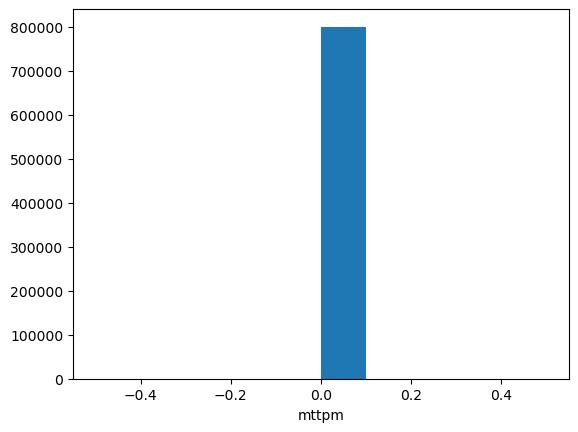

In [18]:
# Anomalies + Plot

nino_3d_anom = nino_3d_comp-data_3d_comp
nina_3d_anom = nina_3d_comp-data_3d_comp


#plot_lev = nino_3d_anom.sel(plev=50000).squeeze()
nino_3d_anom.plot()
print(plot_lev.values)